# Evolutionary Algorithms for Adaptive Business Rule Optimization
## TransUnion Capstone — IDS 560 | Combined GA Pipeline

---

### What This Notebook Does

This is the **single unified pipeline** for the TransUnion fraud rule optimization project.
It consolidates all prior notebooks into one reproducible end-to-end workflow.

| Stage | Description |
|---|---|
| **1. Data** | Load, clean, and split the credit card fraud dataset |
| **2. Splits** | Two modes: stratified random split OR time-ordered (in-time / out-of-time) split |
| **3. Feature Engineering** | V10 decile binning (train-fit only) + feature screening via mutual information |
| **4. Baseline GA** | Single-rule evolution: one AND-rule evolved over generations (Algorithm v1) |
| **5. Coevolution GA** | Dual-population rule set evolution: paths + rule sets co-evolve (Algorithm v2) |
| **6. Stability Analysis** | Multi-seed runs to validate reproducibility |
| **7. Pareto Analysis** | Operating point selection: conservative / balanced / aggressive |
| **8. Results & Export** | Metrics, plots, JSON export, and comparison summary |

---

### Key Design Decisions (confirmed with sponsors)

- **No Time features**: `Time`, `Time_scaled`, `Time_days` are excluded by default — rules using timestamps are dataset-specific and do not generalize to new data
- **Full operator set**: `>`, `>=`, `<`, `<=`, `=` all permitted (vendor constraint formally relaxed Feb 25, 2026)
- **No-duplicate-feature constraint**: each feature appears at most once per rule
- **Individuals are rule sets** (OR-of-AND), not single rules — aligned with TransUnion's rule engine
- **Fitness**: F1 on validation set for paths; multi-component score (F1 + diversity bonus − parsimony penalty) for rule sets
- **Elitism + Hall of Fame**: best solution is never lost
- **Metrics**: precision, recall, F1, alert rate — never raw accuracy (misleading on imbalanced data)

---
## Section 0: Configuration

All parameters are defined here. Adjust before running.

| Parameter | Default | Meaning |
|---|---|---|
| `DATA_FILE` | `"creditcard.csv"` | Path to raw dataset |
| `SPLIT_MODE` | `"stratified"` | `"stratified"` (random) or `"time_ordered"` (in-time/out-of-time) |
| `EXCLUDE_TIME_FEATURES` | `True` | Remove Time/Time_scaled/Time_days from feature pool |
| `TOP_K` | `12` | Number of top features to retain after screening |
| `RANDOM_SEED` | `42` | Primary random seed |
| `STABILITY_SEEDS` | `[11,22,33,44,55]` | Seeds for multi-seed stability runs |
| `RUN_BASELINE_GA` | `True` | Run the single-rule baseline GA |
| `RUN_COEVOLUTION` | `True` | Run the dual-population coevolution GA |
| `RUN_STABILITY` | `True` | Run multi-seed stability analysis |
| `ALPHA` | `0.01` | Max allowed alert rate (1%) for operating point selection |

In [1]:
import os

# ── Split mode ────────────────────────────────────────────────────────────────
# "stratified"   → random stratified 70/15/15 split (standard)
# "time_ordered" → in-time/out-of-time split: train on first 70% by Time,
#                  val on next 15%, test on final 15% (methodological refinement)
SPLIT_MODE = "stratified"

# ── Feature settings ─────────────────────────────────────────────────────────
EXCLUDE_TIME_FEATURES = True          # confirmed standard: no Time-based rules
TOP_K                 = 12            # top features retained after MI screening

# ── Seeds ────────────────────────────────────────────────────────────────────
RANDOM_SEED      = 42
STABILITY_SEEDS  = [11, 22, 33, 44, 55]

# ── Run flags ────────────────────────────────────────────────────────────────
RUN_BASELINE_GA  = True
RUN_COEVOLUTION  = True
RUN_STABILITY    = True

# ── GA hyperparameters ───────────────────────────────────────────────────────
# Baseline GA
BASELINE_POP_SIZE   = 80
BASELINE_GENS       = 30

# Coevolution GA
MAX_NODES_PER_PATH   = 5      # max AND-conditions per rule (sponsor constraint)
MAX_PATHS_PER_RS     = 10     # max OR-paths per rule set
PATH_POP_SIZE        = 60
RULESET_POP_SIZE     = 40
COEVO_CYCLES         = 12
INNER_PATH_GENS      = 5
INNER_RS_GENS        = 5
N_MIGRATE            = 5
HOF_SIZE             = 5
PATH_POP_CAP         = 120
COVERAGE_LAMBDA      = 0.05   # diversity bonus weight
PARSIMONY_MU         = 0.02   # parsimony penalty weight
MIN_TP_FITNESS       = 5      # rule must catch at least this many frauds

# ── Operating point selection ────────────────────────────────────────────────
ALPHA = 0.01                  # max alert rate for Pareto selection

# ── Output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = "/content/outputs_combined"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Split mode:            {SPLIT_MODE}")
print(f"Exclude Time features: {EXCLUDE_TIME_FEATURES}")
print(f"Top-K features:        {TOP_K}")
print(f"Primary seed:          {RANDOM_SEED}")
print(f"Stability seeds:       {STABILITY_SEEDS}")
print(f"Output directory:      {OUTPUT_DIR}")

Split mode:            stratified
Exclude Time features: True
Top-K features:        12
Primary seed:          42
Stability seeds:       [11, 22, 33, 44, 55]
Output directory:      /content/outputs_combined


---
## Section 1: Imports & Setup

In [2]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install -q deap

import copy
import json
import random
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    mutual_info_score, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from deap import base, creator, tools

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("All imports OK.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.9 MB/s eta 0:00:00
All imports OK.


---
## Section 2: Load & Clean Data

In [3]:
# ── Upload creditcard.csv from your local machine ───────────────────────────
# Option 1: Upload directly (recommended for first-time use)
from google.colab import files
print("Please upload creditcard.csv when prompted...")
uploaded = files.upload()
DATA_FILE = list(uploaded.keys())[0]
print(f"Loaded file: {DATA_FILE}")


# ── Load & clean ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE)
df = df.drop_duplicates().reset_index(drop=True)
df["Class"] = df["Class"].astype(int)

print(f"Dataset shape:  {df.shape}")
print(f"Fraud rate:     {df['Class'].mean():.4f}  ({df['Class'].sum()} fraud cases)")
print(f"Time range:     {df['Time'].min():.0f}s — {df['Time'].max():.0f}s  "
      f"({df['Time'].max()/3600:.1f} hours total)")


Please upload creditcard.csv when prompted...


Saving creditcard.txt to creditcard.txt
Loaded file: creditcard.txt
Dataset shape:  (283726, 31)
Fraud rate:     0.0017  (473 fraud cases)
Time range:     0s — 172792s  (48.0 hours total)


---
## Section 3: Train / Validation / Test Split

Two modes are supported:

**Stratified (default)** — random 70/15/15 split, stratified on `Class` so fraud rate is consistent across all splits.

**Time-ordered** — splits on the `Time` column: the earliest 70% of transactions go to train, the next 15% to validation, and the final 15% to test. This is the in-time / out-of-time methodology: the model is trained on past data and evaluated on future data, which is closer to real deployment conditions. Recommended by sponsors (Jonah, Meeting #6, March 4 2026).

> Note: time-ordered splits cannot guarantee equal fraud rates across splits — the fraud rate in the test window may differ from train. This is expected and realistic.

In [4]:
X_raw = df.drop(columns=["Class"])
y_raw = df["Class"]

if SPLIT_MODE == "time_ordered":
    # ── In-time / Out-of-time split ───────────────────────────────────────────
    df_sorted = df.sort_values("Time").reset_index(drop=True)
    n = len(df_sorted)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_df = df_sorted.iloc[:train_end]
    val_df   = df_sorted.iloc[train_end:val_end]
    test_df  = df_sorted.iloc[val_end:]

    X_train = train_df.drop(columns=["Class"]).reset_index(drop=True)
    y_train = train_df["Class"].reset_index(drop=True)
    X_val   = val_df.drop(columns=["Class"]).reset_index(drop=True)
    y_val   = val_df["Class"].reset_index(drop=True)
    X_test  = test_df.drop(columns=["Class"]).reset_index(drop=True)
    y_test  = test_df["Class"].reset_index(drop=True)

    print("Split mode: TIME-ORDERED (in-time / out-of-time)")
    print(f"  Train: Time 0 — {train_df['Time'].max():.0f}s")
    print(f"  Val:   Time {val_df['Time'].min():.0f}s — {val_df['Time'].max():.0f}s")
    print(f"  Test:  Time {test_df['Time'].min():.0f}s — {test_df['Time'].max():.0f}s")

else:
    # ── Stratified random split ───────────────────────────────────────────────
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=RANDOM_SEED
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=(0.15/0.85), stratify=y_temp, random_state=RANDOM_SEED
    )
    X_train = X_train.reset_index(drop=True)
    X_val   = X_val.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_val   = y_val.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)
    print("Split mode: STRATIFIED (random)")

print(f"\nTrain: {len(X_train):>7,} rows  |  fraud rate = {y_train.mean():.4f}  ({y_train.sum()} frauds)")
print(f"Val:   {len(X_val):>7,} rows  |  fraud rate = {y_val.mean():.4f}  ({y_val.sum()} frauds)")
print(f"Test:  {len(X_test):>7,} rows  |  fraud rate = {y_test.mean():.4f}  ({y_test.sum()} frauds)")

Split mode: STRATIFIED (random)

Train: 198,608 rows  |  fraud rate = 0.0017  (331 frauds)
Val:    42,559 rows  |  fraud rate = 0.0017  (71 frauds)
Test:   42,559 rows  |  fraud rate = 0.0017  (71 frauds)


---
## Section 4: Feature Engineering

### 4a. V10 Decile Binning (train-fit, applied to all splits)

V10 has the strongest non-linear fraud signal — its lowest decile has a fraud rate ~60× the baseline.
We replace it with an ordinal integer `V10_bin_code` (0–9), fitted on training data only to prevent leakage.

### 4b. Time Feature Exclusion

`Time`, `Time_scaled`, and `Time_days` are excluded by default (`EXCLUDE_TIME_FEATURES = True`).
Rules using timestamps are dataset-specific and would not generalize to production data.
Confirmed as the standard configuration — Meeting #6, March 4 2026.

### 4c. Feature Screening via Mutual Information

Features are ranked by mutual information with the fraud label plus fraud-rate spread across decile bins.
Only the training set is used here — no leakage into validation or test.

In [5]:
# ── 4a: V10 Decile Binning ────────────────────────────────────────────────────
_, v10_bin_edges = pd.qcut(X_train["V10"], q=10, duplicates="drop", retbins=True)
v10_bin_edges[0]  = -np.inf
v10_bin_edges[-1] =  np.inf

def apply_v10_binning(X, edges):
    codes = pd.cut(X["V10"], bins=edges, labels=False, include_lowest=True).astype(int)
    idx   = list(X.columns).index("V10")
    X     = X.drop(columns=["V10"]).copy()
    X.insert(idx, "V10_bin_code", codes.values)
    return X

X_train = apply_v10_binning(X_train, v10_bin_edges)
X_val   = apply_v10_binning(X_val,   v10_bin_edges)
X_test  = apply_v10_binning(X_test,  v10_bin_edges)

# Verify fraud rate by bin on training set
v10_rates = X_train.assign(Class=y_train.values).groupby("V10_bin_code")["Class"].agg(["count", "mean"])
v10_rates.columns = ["n_transactions", "fraud_rate"]
print("Fraud rate by V10 decile bin (train):")
print(v10_rates.to_string())

Fraud rate by V10 decile bin (train):
              n_transactions  fraud_rate
V10_bin_code                            
0                      19861    0.014199
1                      19861    0.000352
2                      19861    0.000151
3                      19860    0.000201
4                      19862    0.000201
5                      19860    0.000151
6                      19860    0.000403
7                      19861    0.000403
8                      19861    0.000352
9                      19861    0.000252


In [6]:
# ── 4b: Exclude Time features ─────────────────────────────────────────────────
TIME_FEATURES = {"Time", "Time_scaled", "Time_days"}

if EXCLUDE_TIME_FEATURES:
    drop_cols = [c for c in TIME_FEATURES if c in X_train.columns]
    X_train = X_train.drop(columns=drop_cols)
    X_val   = X_val.drop(columns=drop_cols)
    X_test  = X_test.drop(columns=drop_cols)
    print(f"Excluded Time features: {drop_cols}")
else:
    print("Time features retained (EXCLUDE_TIME_FEATURES = False)")

print(f"Feature count after Time exclusion: {X_train.shape[1]}")

Excluded Time features: ['Time']
Feature count after Time exclusion: 29


In [7]:
# ── 4c: Feature Screening via Mutual Information ──────────────────────────────
def feature_screen(Xtr, ytr, max_bins=10):
    rows = []
    for col in Xtr.columns:
        uniq = Xtr[col].nunique()
        if uniq < 3:
            continue
        try:
            b = pd.qcut(Xtr[col], q=min(max_bins, uniq), duplicates="drop")
        except Exception:
            continue
        tmp = pd.DataFrame({"bin": b, "Class": ytr}).dropna()
        if tmp["bin"].nunique() < 2:
            continue
        spread = float(tmp.groupby("bin", observed=True)["Class"].mean().pipe(
            lambda s: s.max() - s.min()))
        mi = float(mutual_info_score(tmp["bin"].cat.codes, tmp["Class"]))
        rows.append({"feature": col, "mi": mi, "spread": spread})
    return pd.DataFrame(rows).sort_values(["mi", "spread"], ascending=False)

rank_df = feature_screen(X_train, y_train)
TOP_FEATURES = rank_df["feature"].head(TOP_K).tolist()

# Always keep V10_bin_code — it's a deliberate engineered feature
if "V10_bin_code" not in TOP_FEATURES:
    TOP_FEATURES.append("V10_bin_code")
    print("Note: V10_bin_code added (not in top-K by MI but required).")

X_train = X_train[TOP_FEATURES]
X_val   = X_val[TOP_FEATURES]
X_test  = X_test[TOP_FEATURES]

print(f"\nTop {len(TOP_FEATURES)} features selected:")
print(rank_df.head(TOP_K).to_string(index=False))


Top 12 features selected:
     feature       mi   spread
         V14 0.003070 0.015155
          V4 0.002720 0.014199
V10_bin_code 0.002622 0.014048
         V12 0.002574 0.013846
         V11 0.002438 0.013544
         V17 0.002370 0.012739
          V3 0.002295 0.013041
         V16 0.002166 0.012537
          V7 0.002044 0.012285
          V2 0.001871 0.011681
          V9 0.001564 0.010674
         V21 0.001538 0.010221


---
## Section 5: Shared Utilities

Evaluation metrics, rule application, and pretty-printing functions used by both the baseline GA and the coevolution GA.

In [8]:
# ── Structural constants ──────────────────────────────────────────────────────
CATEGORICAL_FEATURES = {"V10_bin_code"}
CONTINUOUS_OPS       = [">", ">=", "<", "<="]
CATEGORICAL_OPS      = [">", ">=", "=", "<", "<="]
OP_FUNCS = {
    ">":  lambda x, t: x > t,
    ">=": lambda x, t: x >= t,
    "=":  lambda x, t: x == t,
    "<":  lambda x, t: x < t,
    "<=": lambda x, t: x <= t,
}

FEATURES = list(X_train.columns)

# Threshold bank — fitted on training data only
quantiles = np.linspace(0.05, 0.95, 19)
threshold_bank = {}
for col in FEATURES:
    if col in CATEGORICAL_FEATURES:
        threshold_bank[col] = np.arange(X_train[col].nunique(), dtype=float)
    else:
        threshold_bank[col] = np.quantile(X_train[col].values, quantiles)

# ── Metrics ───────────────────────────────────────────────────────────────────
def evaluate_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    alert  = float(y_pred.sum()) / len(y_pred) if len(y_pred) > 0 else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": prec, "recall": rec, "f1": f1, "alert_rate": alert}

# ── Path (single AND-rule) application ───────────────────────────────────────
def apply_path(path, Xdf):
    """Returns boolean array: True where ALL conditions in the path are satisfied."""
    mask = np.ones(len(Xdf), dtype=bool)
    for col, op, thr in path:
        mask &= OP_FUNCS[op](Xdf[col].values, thr)
    return mask

# ── Rule set (OR-of-AND) application ─────────────────────────────────────────
def apply_ruleset(ruleset, Xdf):
    """Returns integer array: 1 where ANY path fires."""
    mask = np.zeros(len(Xdf), dtype=bool)
    for path in ruleset:
        mask |= apply_path(path, Xdf)
    return mask.astype(int)

# ── Pretty-print helpers ──────────────────────────────────────────────────────
def pretty_path(path):
    parts = []
    for col, op, thr in path:
        val = int(thr) if col in CATEGORICAL_FEATURES else f"{thr:.4f}"
        parts.append(f"{col} {op} {val}")
    return "  AND  ".join(parts)

def pretty_ruleset(ruleset):
    lines = []
    for i, path in enumerate(ruleset, 1):
        lines.append(f"  Rule {i}: {pretty_path(path)}")
    return "\n".join(lines)

print(f"Utilities ready. Features ({len(FEATURES)}): {FEATURES}")

Utilities ready. Features (12): ['V14', 'V4', 'V10_bin_code', 'V12', 'V11', 'V17', 'V3', 'V16', 'V7', 'V2', 'V9', 'V21']


---
## Section 6: Baseline GA — Single Rule Evolution (Algorithm v1)

Each individual is a **single AND-rule** of 1–5 conditions.
Fitness = F1 on the validation set.
This serves as the baseline to compare against the coevolution GA.

**Algorithm v2 upgrades applied here too:**
- Full operator set (`>`, `>=`, `<`, `<=`, `=`)
- No-duplicate-feature constraint
- Per-generation F1 logging
- Elitism: best rule always survives

In [9]:
if not RUN_BASELINE_GA:
    print("Skipping Baseline GA (RUN_BASELINE_GA = False)")
else:
    # ── Constants ────────────────────────────────────────────────────────────
    MIN_NODES_BASELINE = 1
    MAX_NODES_BASELINE = 5

    # ── Random condition / rule constructors ─────────────────────────────────
    def random_condition_base(exclude=None):
        exclude = exclude or set()
        available = [f for f in FEATURES if f not in exclude]
        if not available:
            available = FEATURES
        col = random.choice(available)
        ops = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
        return (col, random.choice(ops), float(random.choice(threshold_bank[col])))

    def random_rule_base():
        k = random.randint(MIN_NODES_BASELINE, MAX_NODES_BASELINE)
        rule, used = [], set()
        for _ in range(k):
            cond = random_condition_base(exclude=used)
            rule.append(cond)
            used.add(cond[0])
        return rule

    # ── DEAP setup ───────────────────────────────────────────────────────────
    if "FitnessMaxBase" not in creator.__dict__:
        creator.create("FitnessMaxBase", base.Fitness, weights=(1.0,))
    if "IndividualBase" not in creator.__dict__:
        creator.create("IndividualBase", list, fitness=creator.FitnessMaxBase)

    base_tb = base.Toolbox()
    base_tb.register("individual", tools.initIterate, creator.IndividualBase, random_rule_base)
    base_tb.register("population", tools.initRepeat, list, base_tb.individual)
    base_tb.register("select",     tools.selTournament, tournsize=3)
    base_tb.register("clone",      copy.deepcopy)

    def fitness_base(ind):
        y_pred = apply_path(ind, X_val).astype(int)
        # Require minimum TP before rewarding fitness
        if int(y_pred.sum()) == 0 or int((y_pred * np.asarray(y_val)).sum()) < MIN_TP_FITNESS:
            return (0.0,)
        return (f1_score(y_val, y_pred, zero_division=0),)

    def deduplicate_base(ind):
        """Remove duplicate-feature conditions, keeping the first occurrence.
        Called after crossover to guarantee the no-duplicate-feature constraint."""
        seen, out = set(), []
        for cond in ind:
            if cond[0] not in seen:
                out.append(cond)
                seen.add(cond[0])
        # Must keep at least one condition
        if not out:
            out = [random_condition_base()]
        ind[:] = out
        return ind

    def mutate_base(ind):
        op = random.choice(["thr", "flip", "replace", "add", "drop"])
        if op == "thr" and len(ind) > 0:
            # Shift threshold only — feature and operator unchanged, no duplicate risk
            i = random.randrange(len(ind))
            col, cur_op, _ = ind[i]
            ind[i] = (col, cur_op, float(random.choice(threshold_bank[col])))
        elif op == "flip" and len(ind) > 0:
            # Switch operator only — feature and threshold unchanged, no duplicate risk
            i = random.randrange(len(ind))
            col, cur_op, thr = ind[i]
            pool = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
            other = [o for o in pool if o != cur_op]
            ind[i] = (col, random.choice(other), thr)
        elif op == "replace" and len(ind) > 0:
            # Replace entire condition — exclude ALL currently used features except
            # the one being replaced, so the new condition cannot introduce a duplicate
            i    = random.randrange(len(ind))
            used = {c for c, _, _ in ind} - {ind[i][0]}
            ind[i] = random_condition_base(exclude=used)
        elif op == "add" and len(ind) < MAX_NODES_BASELINE:
            # Append a condition on a feature not already in the rule
            used = {c for c, _, _ in ind}
            ind.append(random_condition_base(exclude=used))
        elif op == "drop" and len(ind) > MIN_NODES_BASELINE:
            ind.pop(random.randrange(len(ind)))
        return (ind,)

    def cx_base(ind1, ind2):
        """Swap one condition between two rules.
        After swapping, deduplicate both children to restore the
        no-duplicate-feature constraint — the swapped condition may
        introduce a feature that already exists in the receiving rule."""
        if len(ind1) > 0 and len(ind2) > 0:
            i, j = random.randrange(len(ind1)), random.randrange(len(ind2))
            ind1[i], ind2[j] = copy.deepcopy(ind2[j]), copy.deepcopy(ind1[i])
            deduplicate_base(ind1)
            deduplicate_base(ind2)
        return ind1, ind2

    base_tb.register("evaluate", fitness_base)
    base_tb.register("mutate",   mutate_base)
    base_tb.register("mate",     cx_base)

    # ── Evolution loop ───────────────────────────────────────────────────────
    def run_baseline_ga(pop_size=BASELINE_POP_SIZE, generations=BASELINE_GENS):
        pop     = base_tb.population(n=pop_size)
        hof     = tools.HallOfFame(1)
        history = []

        for ind in pop:
            ind.fitness.values = base_tb.evaluate(ind)
        hof.update(pop)

        for g in range(generations):
            # Elitism: carry best forward
            elite    = [base_tb.clone(hof[0])]
            offspring = list(map(base_tb.clone, base_tb.select(pop, pop_size - 1)))

            for c1, c2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < 0.4:
                    base_tb.mate(c1, c2)
                    del c1.fitness.values, c2.fitness.values

            for ind in offspring:
                if random.random() < 0.4:
                    base_tb.mutate(ind)
                    del ind.fitness.values

            for ind in offspring:
                if not ind.fitness.valid:
                    ind.fitness.values = base_tb.evaluate(ind)

            pop[:] = elite + offspring
            hof.update(pop)

            best_f1 = hof[0].fitness.values[0]
            avg_f1  = float(np.mean([ind.fitness.values[0] for ind in pop]))
            history.append({"gen": g, "best_f1": best_f1, "avg_f1": avg_f1})

            if g % 5 == 0:
                print(f"  Gen {g:3d} | Best F1: {best_f1:.4f} | Avg F1: {avg_f1:.4f}")

        return hof[0], pd.DataFrame(history)

    print(f"Running Baseline GA: {BASELINE_POP_SIZE} individuals, {BASELINE_GENS} generations...")
    best_baseline_rule, baseline_history = run_baseline_ga()
    print(f"\nBaseline GA complete.")
    print(f"Best rule: {pretty_path(best_baseline_rule)}")

Running Baseline GA: 80 individuals, 30 generations...
  Gen   0 | Best F1: 0.6667 | Avg F1: 0.1037
  Gen   5 | Best F1: 0.7612 | Avg F1: 0.5002
  Gen  10 | Best F1: 0.7669 | Avg F1: 0.5844
  Gen  15 | Best F1: 0.7826 | Avg F1: 0.6514
  Gen  20 | Best F1: 0.7883 | Avg F1: 0.5622
  Gen  25 | Best F1: 0.7883 | Avg F1: 0.5816

Baseline GA complete.
Best rule: V16 <= -1.0568  AND  V4 > -1.3564  AND  V14 < -0.4262  AND  V10_bin_code < 2  AND  V12 <= -0.7819


BASELINE GA — Best Single Rule
V16 <= -1.0568  AND  V4 > -1.3564  AND  V14 < -0.4262  AND  V10_bin_code < 2  AND  V12 <= -0.7819
  Nodes: 5

  Val  → Precision: 0.8182  Recall: 0.7606  F1: 0.7883  Alert rate: 0.0016
  Test → Precision: 0.8448  Recall: 0.6901  F1: 0.7597  Alert rate: 0.0014


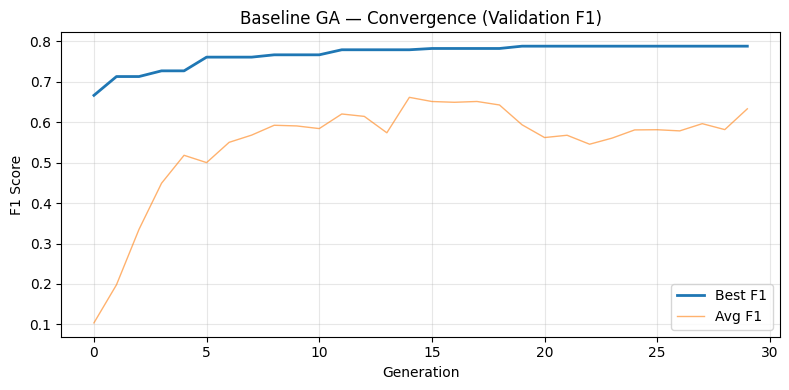

In [10]:
if RUN_BASELINE_GA:
    # ── Evaluate best baseline rule ───────────────────────────────────────────
    val_pred_base  = apply_path(best_baseline_rule, X_val).astype(int)
    test_pred_base = apply_path(best_baseline_rule, X_test).astype(int)

    baseline_val_metrics  = evaluate_metrics(y_val,  val_pred_base)
    baseline_test_metrics = evaluate_metrics(y_test, test_pred_base)

    print("BASELINE GA — Best Single Rule")
    print("=" * 60)
    print(pretty_path(best_baseline_rule))
    print(f"  Nodes: {len(best_baseline_rule)}")
    print(f"\n  Val  → Precision: {baseline_val_metrics['precision']:.4f}  "
          f"Recall: {baseline_val_metrics['recall']:.4f}  "
          f"F1: {baseline_val_metrics['f1']:.4f}  "
          f"Alert rate: {baseline_val_metrics['alert_rate']:.4f}")
    print(f"  Test → Precision: {baseline_test_metrics['precision']:.4f}  "
          f"Recall: {baseline_test_metrics['recall']:.4f}  "
          f"F1: {baseline_test_metrics['f1']:.4f}  "
          f"Alert rate: {baseline_test_metrics['alert_rate']:.4f}")

    # ── Convergence plot ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(baseline_history["gen"], baseline_history["best_f1"], label="Best F1", linewidth=2)
    ax.plot(baseline_history["gen"], baseline_history["avg_f1"],  label="Avg F1",  linewidth=1, alpha=0.6)
    ax.set_xlabel("Generation"); ax.set_ylabel("F1 Score")
    ax.set_title("Baseline GA — Convergence (Validation F1)")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/baseline_convergence.png", dpi=150)
    plt.show()

---
## Section 7: Coevolution GA — Rule Set Evolution (Algorithm v2)

Two co-evolving populations:

| Population | What evolves | Fitness |
|---|---|---|
| **Path pool** | Single AND-rules (≤ `MAX_NODES_PER_PATH` conditions) | Standalone F1 on validation set |
| **Rule set pool** | OR-combinations of paths (≤ `MAX_PATHS_PER_RS`) | F1 + diversity bonus − parsimony penalty |

Migration links the two populations every cycle:
- Best standalone paths → seeded into rule sets (building blocks)
- Paths extracted from best rule sets → promoted back into path pool (collaborative paths surface)

Hall of Fame preserves the globally best individuals across all generations.

In [11]:
if not RUN_COEVOLUTION:
    print("Skipping Coevolution GA (RUN_COEVOLUTION = False)")
else:
    # ── Pre-compute fraud indices on val set (used in fitness) ────────────────
    _fraud_idx_val      = np.where(np.asarray(y_val) == 1)[0]
    _fraud_mask_train   = (np.asarray(y_train) == 1)
    _fraud_X_train      = X_train[_fraud_mask_train].reset_index(drop=True)

    # ── Condition / path / ruleset constructors ───────────────────────────────
    def random_condition_co(exclude=None):
        exclude   = exclude or set()
        available = [f for f in FEATURES if f not in exclude]
        if not available:
            available = FEATURES
        col = random.choice(available)
        ops = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
        return (col, random.choice(ops), float(random.choice(threshold_bank[col])))

    def deduplicate_path(path):
        seen, out = set(), []
        for cond in path:
            if cond[0] not in seen:
                out.append(cond)
                seen.add(cond[0])
        return out if out else [random_condition_co()]

    def random_path_co():
        k, used, path = random.randint(1, MAX_NODES_PER_PATH), set(), []
        for _ in range(k):
            cond = random_condition_co(exclude=used)
            path.append(cond)
            used.add(cond[0])
        return path

    def random_ruleset_co():
        n = random.randint(1, MAX_PATHS_PER_RS)
        return [random_path_co() for _ in range(n)]

    # ── DEAP creators ────────────────────────────────────────────────────────
    if "PathFitness" not in creator.__dict__:
        creator.create("PathFitness", base.Fitness, weights=(1.0,))
    if "Path" not in creator.__dict__:
        creator.create("Path", list, fitness=creator.PathFitness)
    if "RulesetFitness" not in creator.__dict__:
        creator.create("RulesetFitness", base.Fitness, weights=(1.0,))
    if "Ruleset" not in creator.__dict__:
        creator.create("Ruleset", list, fitness=creator.RulesetFitness)

    # ── Fitness functions ─────────────────────────────────────────────────────
    def eval_path_co(path):
        y_pred = apply_path(path, X_val).astype(int)
        tp = int((y_pred * np.asarray(y_val)).sum())
        if tp < MIN_TP_FITNESS:
            return (0.0,)
        return (f1_score(y_val, y_pred, zero_division=0),)

    def eval_ruleset_co(ruleset):
        y_pred  = apply_ruleset(ruleset, X_val)
        alert   = float(y_pred.sum()) / len(y_pred)
        base_f1 = f1_score(y_val, y_pred, zero_division=0)

        # Diversity bonus: paths that catch fraud no other path catches
        if len(ruleset) > 1 and len(_fraud_idx_val) > 0:
            fires = [apply_path(p, X_val)[_fraud_idx_val] for p in ruleset]
            unique_total = 0
            for i, mask_i in enumerate(fires):
                others = np.zeros(len(_fraud_idx_val), dtype=bool)
                for j, mask_j in enumerate(fires):
                    if j != i:
                        others |= mask_j
                unique_total += int((mask_i & ~others).sum())
            diversity = unique_total / (len(_fraud_idx_val) * len(ruleset))
        else:
            diversity = 0.0

        # Parsimony penalty: prefer simpler rule sets
        avg_nodes = np.mean([len(p) for p in ruleset]) if ruleset else 0
        parsimony = 0.5 * (len(ruleset) / MAX_PATHS_PER_RS) + \
                    0.5 * (avg_nodes / MAX_NODES_PER_PATH)

        score = base_f1 + COVERAGE_LAMBDA * diversity - PARSIMONY_MU * parsimony
        return (max(score, 0.0),)

    # ── Toolboxes ────────────────────────────────────────────────────────────
    path_tb = base.Toolbox()
    path_tb.register("individual", tools.initIterate, creator.Path, random_path_co)
    path_tb.register("population", tools.initRepeat, list, path_tb.individual)
    path_tb.register("evaluate",   eval_path_co)
    path_tb.register("select",     tools.selTournament, tournsize=3)
    path_tb.register("clone",      copy.deepcopy)

    rs_tb = base.Toolbox()
    rs_tb.register("individual", tools.initIterate, creator.Ruleset, random_ruleset_co)
    rs_tb.register("population", tools.initRepeat, list, rs_tb.individual)
    rs_tb.register("evaluate",   eval_ruleset_co)
    rs_tb.register("select",     tools.selTournament, tournsize=3)
    rs_tb.register("clone",      copy.deepcopy)

    print("Coevolution toolboxes ready.")

Coevolution toolboxes ready.


In [12]:
if RUN_COEVOLUTION:
    # ── Genetic operators ─────────────────────────────────────────────────────
    def mutate_path_co(path):
        op = random.choice(["thr", "flip", "replace", "add_node", "drop_node"])
        if op == "thr" and len(path) > 0:
            i = random.randrange(len(path))
            col, cur_op, _ = path[i]
            path[i] = (col, cur_op, float(random.choice(threshold_bank[col])))
        elif op == "flip" and len(path) > 0:
            i = random.randrange(len(path))
            col, cur_op, thr = path[i]
            pool  = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
            other = [o for o in pool if o != cur_op]
            path[i] = (col, random.choice(other), thr)
        elif op == "replace" and len(path) > 0:
            i    = random.randrange(len(path))
            used = {c for c, _, _ in path} - {path[i][0]}
            path[i] = random_condition_co(exclude=used)
        elif op == "add_node" and len(path) < MAX_NODES_PER_PATH:
            used = {c for c, _, _ in path}
            path.append(random_condition_co(exclude=used))
        elif op == "drop_node" and len(path) > 1:
            path.pop(random.randrange(len(path)))
        return (path,)

    def cx_paths_co(p1, p2):
        if len(p1) > 0 and len(p2) > 0:
            i, j = random.randrange(len(p1)), random.randrange(len(p2))
            p1[i], p2[j] = copy.deepcopy(p2[j]), copy.deepcopy(p1[i])
            p1[:] = deduplicate_path(p1)
            p2[:] = deduplicate_path(p2)
        return p1, p2

    def mutate_ruleset_co(rs):
        op = random.choice(["add_path", "drop_path", "mutate_node"])
        if op == "add_path" and len(rs) < MAX_PATHS_PER_RS:
            rs.append(random_path_co())
        elif op == "drop_path" and len(rs) > 1:
            rs.pop(random.randrange(len(rs)))
        elif op == "mutate_node" and len(rs) > 0:
            i = random.randrange(len(rs))
            rs[i] = list(mutate_path_co(list(rs[i]))[0])
        return (rs,)

    def cx_rulesets_co(rs1, rs2):
        if len(rs1) > 0 and len(rs2) > 0:
            i, j = random.randrange(len(rs1)), random.randrange(len(rs2))
            rs1[i], rs2[j] = copy.deepcopy(rs2[j]), copy.deepcopy(rs1[i])
        return rs1, rs2

    path_tb.register("mutate", mutate_path_co)
    path_tb.register("mate",   cx_paths_co)
    rs_tb.register("mutate",   mutate_ruleset_co)
    rs_tb.register("mate",     cx_rulesets_co)

    # ── Evolution step (with elitism) ─────────────────────────────────────────
    def evo_step(pop, tb, cx_prob=0.5, mut_prob=0.4, n_elite=1):
        elite    = [tb.clone(e) for e in tools.selBest(pop, n_elite)]
        offspring = list(map(tb.clone, tb.select(pop, len(pop) - n_elite)))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cx_prob:
                tb.mate(c1, c2)
                del c1.fitness.values, c2.fitness.values
        for ind in offspring:
            if random.random() < mut_prob:
                tb.mutate(ind)
                del ind.fitness.values
        for ind in offspring:
            if not ind.fitness.valid:
                ind.fitness.values = tb.evaluate(ind)
        return elite + offspring

    # ── Migration ─────────────────────────────────────────────────────────────
    def migrate_paths_to_rulesets(path_pop, rs_pop, n=N_MIGRATE):
        for path in tools.selBest(path_pop, n):
            target = random.choice(rs_pop)
            if len(target) < MAX_PATHS_PER_RS:
                target.append(copy.deepcopy(path))
            else:
                target[random.randrange(len(target))] = copy.deepcopy(path)
            del target.fitness.values

    def migrate_rulesets_to_paths(rs_pop, path_pop, n=3, cap=PATH_POP_CAP):
        for rs in tools.selBest(rs_pop, n):
            for raw_path in rs:
                p = creator.Path(copy.deepcopy(raw_path))
                p.fitness.values = path_tb.evaluate(p)
                path_pop.append(p)
        path_pop.sort(key=lambda x: x.fitness.values[0], reverse=True)
        del path_pop[cap:]

    print("Coevolution operators and migration ready.")

Coevolution operators and migration ready.


In [13]:
if RUN_COEVOLUTION:
    # ── Main coevolution loop ─────────────────────────────────────────────────
    def run_coevolution(seed=RANDOM_SEED):
        random.seed(seed)
        np.random.seed(seed)

        path_pop = path_tb.population(n=PATH_POP_SIZE)
        rs_pop   = rs_tb.population(n=RULESET_POP_SIZE)

        for p in path_pop: p.fitness.values = path_tb.evaluate(p)
        for r in rs_pop:   r.fitness.values = rs_tb.evaluate(r)

        path_hof = tools.HallOfFame(HOF_SIZE)
        rs_hof   = tools.HallOfFame(HOF_SIZE)
        path_hof.update(path_pop)
        rs_hof.update(rs_pop)

        coevo_history = []

        print(f"  Seed={seed} | {PATH_POP_SIZE} paths, {RULESET_POP_SIZE} rule sets, "
              f"{COEVO_CYCLES} cycles")

        for cycle in range(1, COEVO_CYCLES + 1):
            # Evolve paths
            for _ in range(INNER_PATH_GENS):
                path_pop = evo_step(path_pop, path_tb)
            path_hof.update(path_pop)

            # Migrate: best paths → rule sets
            migrate_paths_to_rulesets(path_pop, rs_pop)

            # Evolve rule sets
            for _ in range(INNER_RS_GENS):
                rs_pop = evo_step(rs_pop, rs_tb)
            rs_hof.update(rs_pop)

            # Migrate: paths inside best rule sets → path pool
            migrate_rulesets_to_paths(rs_pop, path_pop)

            # Log
            best_rs     = rs_hof[0]
            rs_pred     = apply_ruleset(best_rs, X_val)
            rs_true_f1  = f1_score(y_val, rs_pred, zero_division=0)
            alert       = float(rs_pred.sum()) / len(rs_pred)
            coevo_history.append({
                "cycle": cycle,
                "best_path_f1": path_hof[0].fitness.values[0],
                "best_rs_f1":   rs_true_f1,
                "best_rs_alert_rate": alert,
                "best_rs_n_paths":    len(best_rs),
            })

            if cycle % 2 == 0 or cycle == COEVO_CYCLES:
                print(f"  Cycle {cycle:2d}/{COEVO_CYCLES} | "
                      f"Path F1: {path_hof[0].fitness.values[0]:.4f} | "
                      f"RS F1: {rs_true_f1:.4f} | "
                      f"Paths: {len(best_rs)} | Alert: {alert:.4f}")

        return path_hof[0], rs_hof[0], pd.DataFrame(coevo_history), path_hof, rs_hof

    print("Running Coevolution GA (primary seed)...")
    best_path, best_ruleset, coevo_history, path_hof, rs_hof = run_coevolution(seed=RANDOM_SEED)
    print("\nCoevolution complete.")

Running Coevolution GA (primary seed)...
  Seed=42 | 60 paths, 40 rule sets, 12 cycles
  Cycle  2/12 | Path F1: 0.7571 | RS F1: 0.7006 | Paths: 1 | Alert: 0.0020
  Cycle  4/12 | Path F1: 0.7794 | RS F1: 0.7634 | Paths: 2 | Alert: 0.0014
  Cycle  6/12 | Path F1: 0.7883 | RS F1: 0.7634 | Paths: 2 | Alert: 0.0014
  Cycle  8/12 | Path F1: 0.7883 | RS F1: 0.7857 | Paths: 2 | Alert: 0.0016
  Cycle 10/12 | Path F1: 0.7971 | RS F1: 0.7914 | Paths: 2 | Alert: 0.0016
  Cycle 12/12 | Path F1: 0.8085 | RS F1: 0.8169 | Paths: 2 | Alert: 0.0017

Coevolution complete.


COEVOLUTION GA — Best Rule Set
  Rule 1: V16 <= -0.1230  AND  V14 <= -1.4372  AND  V12 <= -1.1373  AND  V10_bin_code <= 0  AND  V4 >= -0.6978
  Rule 2: V17 < -0.9812  AND  V4 > -0.0194  AND  V3 < -0.6104  AND  V2 > 1.1081  AND  V14 < -0.0355

  Paths: 2 | Nodes per path: [5, 5]

  Val  → Precision: 0.8169  Recall: 0.8169  F1: 0.8169  Alert: 0.0017
  Test → Precision: 0.8033  Recall: 0.6901  F1: 0.7424  Alert: 0.0014


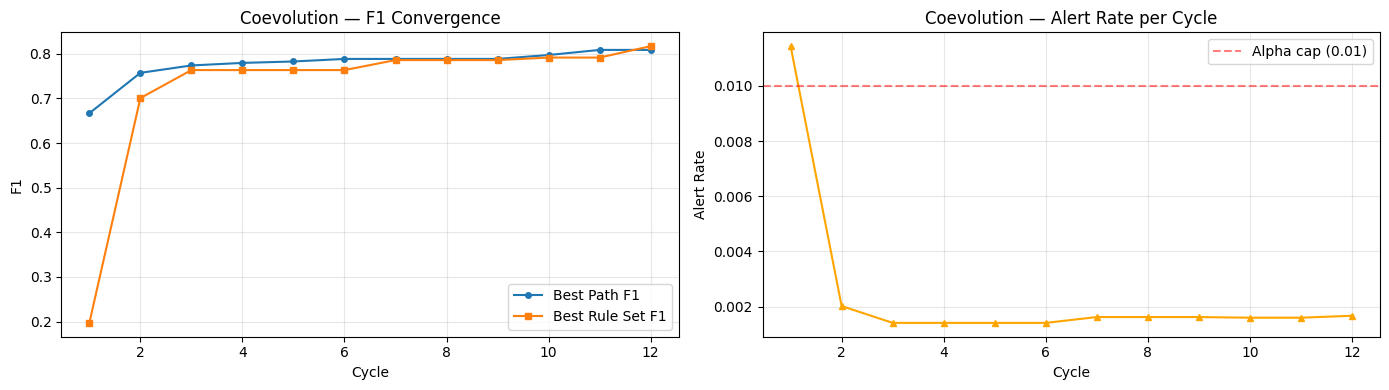

In [14]:
if RUN_COEVOLUTION:
    # ── Evaluate best rule set ────────────────────────────────────────────────
    val_pred_co   = apply_ruleset(best_ruleset, X_val)
    test_pred_co  = apply_ruleset(best_ruleset, X_test)
    co_val_metrics  = evaluate_metrics(y_val,  val_pred_co)
    co_test_metrics = evaluate_metrics(y_test, test_pred_co)

    print("COEVOLUTION GA — Best Rule Set")
    print("=" * 70)
    print(pretty_ruleset(best_ruleset))
    print(f"\n  Paths: {len(best_ruleset)} | Nodes per path: {[len(p) for p in best_ruleset]}")
    print(f"\n  Val  → Precision: {co_val_metrics['precision']:.4f}  "
          f"Recall: {co_val_metrics['recall']:.4f}  "
          f"F1: {co_val_metrics['f1']:.4f}  "
          f"Alert: {co_val_metrics['alert_rate']:.4f}")
    print(f"  Test → Precision: {co_test_metrics['precision']:.4f}  "
          f"Recall: {co_test_metrics['recall']:.4f}  "
          f"F1: {co_test_metrics['f1']:.4f}  "
          f"Alert: {co_test_metrics['alert_rate']:.4f}")

    # ── Convergence plot ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(coevo_history["cycle"], coevo_history["best_path_f1"],
                 label="Best Path F1", marker="o", markersize=4)
    axes[0].plot(coevo_history["cycle"], coevo_history["best_rs_f1"],
                 label="Best Rule Set F1", marker="s", markersize=4)
    axes[0].set_xlabel("Cycle"); axes[0].set_ylabel("F1")
    axes[0].set_title("Coevolution — F1 Convergence")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(coevo_history["cycle"], coevo_history["best_rs_alert_rate"],
                 color="orange", marker="^", markersize=4)
    axes[1].axhline(ALPHA, color="red", linestyle="--", alpha=0.5, label=f"Alpha cap ({ALPHA})")
    axes[1].set_xlabel("Cycle"); axes[1].set_ylabel("Alert Rate")
    axes[1].set_title("Coevolution — Alert Rate per Cycle")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/coevo_convergence.png", dpi=150)
    plt.show()

---
## Section 8: Pareto Front & Operating Points

Build the Pareto front from the rule set Hall of Fame and select three operating points:

| Point | Objective | Alert rate cap | Min support |
|---|---|---|---|
| **Conservative** | Max precision | ≤ 0.05% | val TP ≥ 5 |
| **Balanced** | Max F2 (recall-weighted) | ≤ 0.20% | val TP ≥ 10 |
| **Aggressive** | Max recall | ≤ 1.00% | val precision ≥ 0.10 |

In [15]:
if RUN_COEVOLUTION:
    # ── Build Pareto front from Hall of Fame ──────────────────────────────────
    pareto_rows = []
    for rs in list(rs_hof):
        vp = apply_ruleset(rs, X_val)
        m  = evaluate_metrics(y_val, vp)
        rule_str = pretty_ruleset(rs)
        pareto_rows.append({
            "precision":        m["precision"],
            "recall":           m["recall"],
            "f1":               m["f1"],
            "alert_rate":       m["alert_rate"],
            "n_rules":          len(rs),
            "total_conditions": sum(len(p) for p in rs),
            "rule_set_string":  rule_str,
            "ruleset_obj":      rs,
        })

    pareto_df = pd.DataFrame(pareto_rows)
    pareto_df.to_csv(f"{OUTPUT_DIR}/pareto_front.csv", index=False)

    # ── Operating point selection ─────────────────────────────────────────────
    def select_operating_points(df):
        ops = {}

        # Conservative: max precision, alert ≤ 0.05%, val TP ≥ 5
        cand = df[(df["alert_rate"] <= 0.0005)]
        if not cand.empty:
            ops["conservative"] = cand.loc[cand["precision"].idxmax()]

        # Balanced: max F2, alert ≤ 0.20%, val TP ≥ 10
        cand = df[(df["alert_rate"] <= 0.002)]
        if not cand.empty:
            f2 = (5 * cand["precision"] * cand["recall"]) / \
                 (4 * cand["precision"] + cand["recall"] + 1e-12)
            ops["balanced"] = cand.loc[f2.idxmax()]

        # Aggressive: max recall, alert ≤ 1%, precision ≥ 0.10
        cand = df[(df["alert_rate"] <= ALPHA) & (df["precision"] >= 0.10)]
        if not cand.empty:
            ops["aggressive"] = cand.loc[cand["recall"].idxmax()]

        return ops

    operating_points = select_operating_points(pareto_df)

    print("Operating Points (Validation Set):")
    print("=" * 70)
    for name, row in operating_points.items():
        print(f"\n[{name.upper()}]")
        print(f"  Precision: {row['precision']:.4f} | Recall: {row['recall']:.4f} | "
              f"F1: {row['f1']:.4f} | Alert rate: {row['alert_rate']:.4f}")
        print(f"  Paths: {int(row['n_rules'])} | Total conditions: {int(row['total_conditions'])}")
        print(f"  Rule set:\n{row['rule_set_string']}")

Operating Points (Validation Set):

[BALANCED]
  Precision: 0.8169 | Recall: 0.8169 | F1: 0.8169 | Alert rate: 0.0017
  Paths: 2 | Total conditions: 10
  Rule set:
  Rule 1: V16 <= -0.1230  AND  V14 <= -1.4372  AND  V12 <= -1.1373  AND  V10_bin_code <= 0  AND  V4 >= -0.6978
  Rule 2: V17 < -0.9812  AND  V4 > -0.0194  AND  V3 < -0.6104  AND  V2 > 1.1081  AND  V14 < -0.0355

[AGGRESSIVE]
  Precision: 0.8169 | Recall: 0.8169 | F1: 0.8169 | Alert rate: 0.0017
  Paths: 2 | Total conditions: 10
  Rule set:
  Rule 1: V16 <= -0.1230  AND  V14 <= -1.4372  AND  V12 <= -1.1373  AND  V10_bin_code <= 0  AND  V4 >= -0.6978
  Rule 2: V17 < -0.9812  AND  V4 > -0.0194  AND  V3 < -0.6104  AND  V2 > 1.1081  AND  V14 < -0.0355


In [16]:
if RUN_COEVOLUTION:
    # ── Evaluate operating points on TEST set ─────────────────────────────────
    print("Operating Points — TEST Set Evaluation")
    print("=" * 70)
    test_op_results = {}
    for name, row in operating_points.items():
        rs  = row["ruleset_obj"]
        tp  = apply_ruleset(rs, X_test)
        m   = evaluate_metrics(y_test, tp)
        test_op_results[name] = m
        print(f"\n[{name.upper()}]")
        print(f"  Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | "
              f"F1: {m['f1']:.4f} | Alert rate: {m['alert_rate']:.4f}")
        print(f"  TP={m['TP']}  FP={m['FP']}  FN={m['FN']}  TN={m['TN']}")

    # Save
    with open(f"{OUTPUT_DIR}/selected_operating_points.json", "w") as f:
        json.dump({
            k: {"val": {"precision": float(v["precision"]),
                        "recall":    float(v["recall"]),
                        "f1":        float(v["f1"]),
                        "alert_rate":float(v["alert_rate"])},
                "rule_set_string": operating_points[k]["rule_set_string"]}
            for k, v in test_op_results.items()
        }, f, indent=2)
    print(f"\nSaved to {OUTPUT_DIR}/selected_operating_points.json")

Operating Points — TEST Set Evaluation

[BALANCED]
  Precision: 0.8033 | Recall: 0.6901 | F1: 0.7424 | Alert rate: 0.0014
  TP=49  FP=12  FN=22  TN=42476

[AGGRESSIVE]
  Precision: 0.8033 | Recall: 0.6901 | F1: 0.7424 | Alert rate: 0.0014
  TP=49  FP=12  FN=22  TN=42476

Saved to /content/outputs_combined/selected_operating_points.json


---
## Section 9: Multi-Seed Stability Analysis

Run the coevolution GA across 5 seeds to validate that results are reproducible — not a lucky starting point.

In [17]:
if not RUN_STABILITY:
    print("Skipping stability analysis (RUN_STABILITY = False)")
elif not RUN_COEVOLUTION:
    print("Skipping stability analysis (requires RUN_COEVOLUTION = True)")
else:
    print(f"Running stability analysis across seeds: {STABILITY_SEEDS}")
    print("=" * 60)
    stability_results = {}

    for seed in STABILITY_SEEDS:
        print(f"\nSeed {seed}:")
        _, best_rs_seed, _, _, rs_hof_seed = run_coevolution(seed=seed)

        # Collect operating points for this seed
        seed_pareto_rows = []
        for rs in list(rs_hof_seed):
            vp = apply_ruleset(rs, X_val)
            m  = evaluate_metrics(y_val, vp)
            seed_pareto_rows.append({
                "precision": m["precision"], "recall": m["recall"],
                "f1": m["f1"], "alert_rate": m["alert_rate"],
                "n_rules": len(rs), "total_conditions": sum(len(p) for p in rs),
                "rule_set_string": pretty_ruleset(rs), "ruleset_obj": rs,
            })
        seed_pareto = pd.DataFrame(seed_pareto_rows)
        seed_ops    = select_operating_points(seed_pareto)

        for name, row in seed_ops.items():
            rs  = row["ruleset_obj"]
            tp  = apply_ruleset(rs, X_test)
            m   = evaluate_metrics(y_test, tp)
            stability_results.setdefault(name, []).append(
                {"seed": seed, **{k: v for k, v in m.items() if k in
                                   ["precision", "recall", "f1", "alert_rate"]}}
            )

    # ── Stability summary ─────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("STABILITY SUMMARY (TEST metrics across 5 seeds)")
    print("=" * 70)
    stab_rows = []
    for name, records in stability_results.items():
        df_s = pd.DataFrame(records)
        row  = {"operating_point": name, "n_seeds": len(df_s)}
        for metric in ["precision", "recall", "f1", "alert_rate"]:
            row[f"{metric}_mean"] = df_s[metric].mean()
            row[f"{metric}_std"]  = df_s[metric].std()
        stab_rows.append(row)
        print(f"\n[{name.upper()}]")
        print(f"  Precision: {row['precision_mean']:.4f} ± {row['precision_std']:.4f}")
        print(f"  Recall:    {row['recall_mean']:.4f} ± {row['recall_std']:.4f}")
        print(f"  F1:        {row['f1_mean']:.4f} ± {row['f1_std']:.4f}")
        print(f"  Alert:     {row['alert_rate_mean']:.4f} ± {row['alert_rate_std']:.4f}")

    stability_df = pd.DataFrame(stab_rows)
    stability_df.to_csv(f"{OUTPUT_DIR}/stability_metrics.csv", index=False)
    print(f"\nStability metrics saved to {OUTPUT_DIR}/stability_metrics.csv")

Running stability analysis across seeds: [11, 22, 33, 44, 55]

Seed 11:
  Seed=11 | 60 paths, 40 rule sets, 12 cycles
  Cycle  2/12 | Path F1: 0.7914 | RS F1: 0.5786 | Paths: 2 | Alert: 0.0021
  Cycle  4/12 | Path F1: 0.7914 | RS F1: 0.6769 | Paths: 1 | Alert: 0.0014
  Cycle  6/12 | Path F1: 0.7914 | RS F1: 0.7634 | Paths: 2 | Alert: 0.0014
  Cycle  8/12 | Path F1: 0.7914 | RS F1: 0.7669 | Paths: 2 | Alert: 0.0015
  Cycle 10/12 | Path F1: 0.7914 | RS F1: 0.7737 | Paths: 2 | Alert: 0.0016
  Cycle 12/12 | Path F1: 0.8058 | RS F1: 0.7852 | Paths: 2 | Alert: 0.0015

Seed 22:
  Seed=22 | 60 paths, 40 rule sets, 12 cycles
  Cycle  2/12 | Path F1: 0.7883 | RS F1: 0.5556 | Paths: 2 | Alert: 0.0026
  Cycle  4/12 | Path F1: 0.8112 | RS F1: 0.5683 | Paths: 2 | Alert: 0.0026
  Cycle  6/12 | Path F1: 0.8227 | RS F1: 0.7121 | Paths: 1 | Alert: 0.0014
  Cycle  8/12 | Path F1: 0.8227 | RS F1: 0.7385 | Paths: 1 | Alert: 0.0014
  Cycle 10/12 | Path F1: 0.8227 | RS F1: 0.7481 | Paths: 1 | Alert: 0.0014
 

---
## Section 10: Pareto Front Visualizations

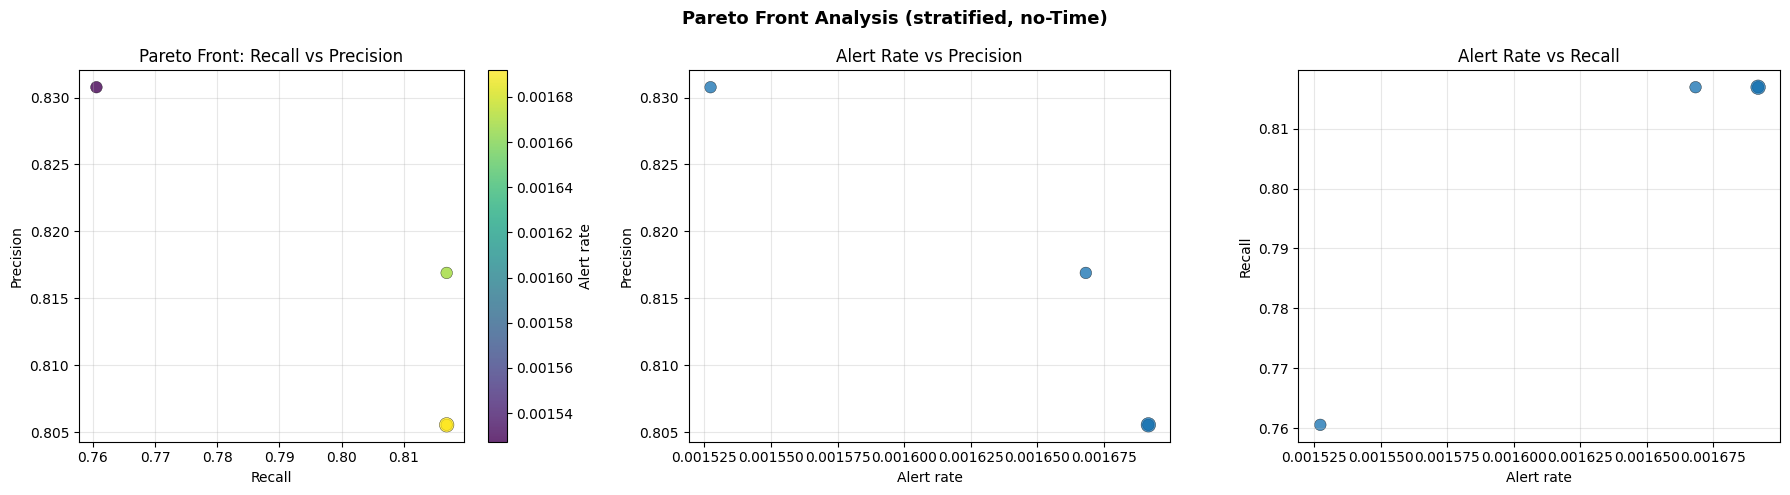

In [18]:
if RUN_COEVOLUTION:
    df_plot = pd.read_csv(f"{OUTPUT_DIR}/pareto_front.csv")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Recall vs Precision
    sc = axes[0].scatter(
        df_plot["recall"], df_plot["precision"],
        c=df_plot["alert_rate"], s=20 + 5 * df_plot["total_conditions"],
        cmap="viridis", alpha=0.8, edgecolors="k", linewidths=0.3
    )
    plt.colorbar(sc, ax=axes[0]).set_label("Alert rate")
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title("Pareto Front: Recall vs Precision")
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Alert rate vs Precision
    axes[1].scatter(
        df_plot["alert_rate"], df_plot["precision"],
        s=20 + 5 * df_plot["total_conditions"], alpha=0.8,
        edgecolors="k", linewidths=0.3
    )
    axes[1].set_xlabel("Alert rate"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Alert Rate vs Precision")
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Alert rate vs Recall
    axes[2].scatter(
        df_plot["alert_rate"], df_plot["recall"],
        s=20 + 5 * df_plot["total_conditions"], alpha=0.8,
        edgecolors="k", linewidths=0.3
    )
    axes[2].set_xlabel("Alert rate"); axes[2].set_ylabel("Recall")
    axes[2].set_title("Alert Rate vs Recall")
    axes[2].grid(True, alpha=0.3)

    suffix = f"({SPLIT_MODE}, {'no-Time' if EXCLUDE_TIME_FEATURES else 'with-Time'})"
    fig.suptitle(f"Pareto Front Analysis {suffix}", fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/pareto_plots.png", dpi=150)
    plt.show()

---
## Section 11: Baseline vs Coevolution Comparison

METHOD COMPARISON (Test Set)
                        Method  Precision  Recall     F1  Alert Rate  # Rules  # Conditions
     Baseline GA (single rule)     0.8448  0.6901 0.7597      0.0014        1             5
Coevolution GA (best rule set)     0.8033  0.6901 0.7424      0.0014        2            10
        Coevolution — balanced     0.8033  0.6901 0.7424      0.0014        2            10
      Coevolution — aggressive     0.8033  0.6901 0.7424      0.0014        2            10


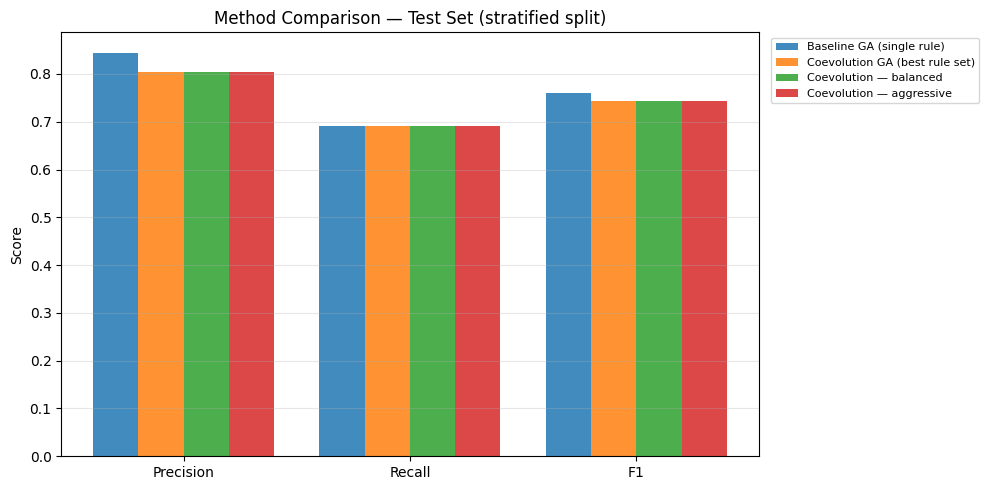

In [19]:
if RUN_BASELINE_GA and RUN_COEVOLUTION:
    print("METHOD COMPARISON (Test Set)")
    print("=" * 70)

    comp_data = [
        {"Method": "Baseline GA (single rule)",
         "Precision": baseline_test_metrics["precision"],
         "Recall":    baseline_test_metrics["recall"],
         "F1":        baseline_test_metrics["f1"],
         "Alert Rate":baseline_test_metrics["alert_rate"],
         "# Rules":   1,
         "# Conditions": len(best_baseline_rule)},
        {"Method": "Coevolution GA (best rule set)",
         "Precision": co_test_metrics["precision"],
         "Recall":    co_test_metrics["recall"],
         "F1":        co_test_metrics["f1"],
         "Alert Rate":co_test_metrics["alert_rate"],
         "# Rules":   len(best_ruleset),
         "# Conditions": sum(len(p) for p in best_ruleset)},
    ]

    for name, row in test_op_results.items():
        op_row = operating_points[name]
        comp_data.append({
            "Method": f"Coevolution — {name}",
            "Precision": row["precision"],
            "Recall":    row["recall"],
            "F1":        row["f1"],
            "Alert Rate":row["alert_rate"],
            "# Rules":   int(op_row["n_rules"]),
            "# Conditions": int(op_row["total_conditions"]),
        })

    comp_df = pd.DataFrame(comp_data)
    comp_df = comp_df.round(4)
    comp_df.to_csv(f"{OUTPUT_DIR}/method_comparison.csv", index=False)
    print(comp_df.to_string(index=False))

    # Bar chart comparison
    metrics_to_plot = ["Precision", "Recall", "F1"]
    x = np.arange(len(metrics_to_plot))
    width = 0.8 / len(comp_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (_, row) in enumerate(comp_df.iterrows()):
        ax.bar(x + i * width, [row[m] for m in metrics_to_plot],
               width, label=row["Method"], alpha=0.85)

    ax.set_xticks(x + width * (len(comp_df) - 1) / 2)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylabel("Score")
    ax.set_title(f"Method Comparison — Test Set ({SPLIT_MODE} split)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/method_comparison.png", dpi=150)
    plt.show()

---
## Section 12: No-Time Leak Verification

Confirm that none of the excluded Time features appear in any evolved rule string.

In [20]:
if EXCLUDE_TIME_FEATURES and RUN_COEVOLUTION:
    patterns = {f: re.compile(r"\b" + re.escape(f) + r"\b") for f in TIME_FEATURES}
    leak_found = False

    all_rule_strings = [row["rule_set_string"] for _, row in pareto_df.iterrows()]
    for rule_str in all_rule_strings:
        for feat, pat in patterns.items():
            if pat.search(rule_str):
                print(f"LEAK DETECTED: '{feat}' found in rule: {rule_str}")
                leak_found = True

    if not leak_found:
        print("PASS: No Time features found in any evolved rule. "
              "Rules are dataset-agnostic and generalizable.")
else:
    print("Leak check skipped (Time features not excluded or coevolution not run).")

PASS: No Time features found in any evolved rule. Rules are dataset-agnostic and generalizable.


---
## Section 13: Export Results

In [21]:
results_summary = {
    "config": {
        "split_mode":             SPLIT_MODE,
        "exclude_time_features":  EXCLUDE_TIME_FEATURES,
        "top_k_features":         TOP_K,
        "top_features":           TOP_FEATURES,
        "random_seed":            RANDOM_SEED,
        "stability_seeds":        STABILITY_SEEDS,
    }
}

if RUN_BASELINE_GA:
    results_summary["baseline_ga"] = {
        "best_rule":    pretty_path(best_baseline_rule),
        "n_conditions": len(best_baseline_rule),
        "val_metrics":  {k: float(v) for k, v in
                         evaluate_metrics(y_val, apply_path(best_baseline_rule, X_val).astype(int)).items()
                         if k not in ["TP","FP","FN","TN"]},
        "test_metrics": {k: float(v) for k, v in baseline_test_metrics.items()
                         if k not in ["TP","FP","FN","TN"]},
    }

if RUN_COEVOLUTION:
    results_summary["coevolution_ga"] = {
        "best_ruleset":   pretty_ruleset(best_ruleset),
        "n_paths":        len(best_ruleset),
        "nodes_per_path": [len(p) for p in best_ruleset],
        "val_metrics":    {k: float(v) for k, v in co_val_metrics.items()
                           if k not in ["TP","FP","FN","TN"]},
        "test_metrics":   {k: float(v) for k, v in co_test_metrics.items()
                           if k not in ["TP","FP","FN","TN"]},
        "operating_points": {
            name: {k: float(v) for k, v in m.items() if k not in ["TP","FP","FN","TN"]}
            for name, m in test_op_results.items()
        }
    }

output_path = f"{OUTPUT_DIR}/results_summary.json"
with open(output_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Results summary saved to: {output_path}")
print(f"\nAll outputs in: {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f"  {fname:<50s}  {os.path.getsize(fpath)/1024:.1f} KB")

Results summary saved to: /content/outputs_combined/results_summary.json

All outputs in: /content/outputs_combined/
  baseline_convergence.png                            46.5 KB
  coevo_convergence.png                               70.8 KB
  method_comparison.csv                               0.3 KB
  method_comparison.png                               46.8 KB
  pareto_front.csv                                    3.6 KB
  pareto_plots.png                                    91.9 KB
  results_summary.json                                2.0 KB
  selected_operating_points.json                      0.8 KB
  stability_metrics.csv                               0.5 KB
